In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 20)

file_path = "/content/vgsales.csv"
games = pd.read_csv(file_path)

games.head()

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=games)

https://docs.google.com/spreadsheets/d/10T2NOQircrQB0R-5PyBZNF9dGcwak5PoMVK6XBaKupE/edit#gid=0


In [ ]:
games.shape

(16598, 11)

In [ ]:
games.columns


Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [ ]:
games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
games.sample(5, random_state=42)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
8928,8930,F1 2012,PC,2012.0,Racing,Codemasters,0.01,0.11,0.00,0.03,0.15
4789,4791,"Transformers: The Game (XBox 360, PS2, PS3, Wi...",PS3,2007.0,Action,Activision,0.32,0.04,0.01,0.04,0.40
15492,15495,Commandos 3: Destination Berlin,PC,2003.0,Strategy,Eidos Interactive,0.00,0.02,0.00,0.00,0.02
14767,14770,The Sims 2: Bon Voyage,PC,2007.0,Simulation,Electronic Arts,0.01,0.01,0.00,0.00,0.03
5211,5213,Guitar Hero: Smash Hits,PS3,2009.0,Misc,Activision,0.20,0.11,0.00,0.05,0.36


In [ ]:
games[games["Year"].isna()].head(20)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
624,625,Rock Band,X360,NaN,Misc,Electronic Arts,1.93,0.34,0.00,0.21,2.48
649,650,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,Konami Digital Entertainment,2.15,0.18,0.00,0.07,2.39
652,653,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,LucasArts,1.54,0.63,0.00,0.22,2.39
711,713,Call of Duty 3,Wii,NaN,Shooter,Activision,1.19,0.84,0.00,0.23,2.26
782,784,Rock Band,Wii,NaN,Misc,MTV Games,1.35,0.56,0.00,0.20,2.11


In [ ]:
time_analysis = games.dropna(subset=["Year"]).copy()

In [ ]:
games["Year_Missing"] = games["Year"].isna()

In [ ]:
games["Year"] = games["Year"].astype("Int64")

In [ ]:
missing_profile = pd.DataFrame({
    "missing_count": games.isna().sum(),
    "missing_percentage": games.isna().mean() * 100
})

missing_profile.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
Year,271,1.632727
Publisher,58,0.349440
Name,0,0.000000
Rank,0,0.000000
Platform,0,0.000000
Genre,0,0.000000
NA_Sales,0,0.000000
EU_Sales,0,0.000000
JP_Sales,0,0.000000
Other_Sales,0,0.000000


In [ ]:
games.duplicated().sum()

np.int64(0)

In [ ]:
games[
    games.duplicated(
        subset=["Name", "Platform", "Year"],
        keep=False
    )
].sort_values(["Name", "Platform", "Year"])

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Year_Missing
603,604,Madden NFL 13,PS3,2012,Sports,Electronic Arts,2.11,0.23,0.00,0.22,2.56,False
16127,16130,Madden NFL 13,PS3,2012,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01,False
14997,15000,Wii de Asobu: Metroid Prime,Wii,<NA>,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02,True
14999,15002,Wii de Asobu: Metroid Prime,Wii,<NA>,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02,True


In [ ]:
games["calculated_global_sales"] = (
    games["NA_Sales"]
    + games["EU_Sales"]
    + games["JP_Sales"]
    + games["Other_Sales"]
)


In [ ]:
games["sales_difference"] = (
    games["Global_Sales"]
    - games["calculated_global_sales"]
)

games["sales_difference"].describe()

,sales_difference
count,16598.000000
mean,0.000277
std,0.005223
min,-0.020000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.020000


In [ ]:
exact_duplicates = games.duplicated().sum()
exact_duplicates

np.int64(0)

In [ ]:
business_duplicates = games[
    games.duplicated(
        subset=["Name", "Platform", "Year"],
        keep=False
    )
].sort_values(["Name", "Platform", "Year"])

business_duplicates

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Year_Missing,calculated_global_sales,sales_difference
603,604,Madden NFL 13,PS3,2012,Sports,Electronic Arts,2.11,0.23,0.00,0.22,2.56,False,2.56,0.0
16127,16130,Madden NFL 13,PS3,2012,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01,False,0.01,0.0
14997,15000,Wii de Asobu: Metroid Prime,Wii,<NA>,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02,True,0.02,0.0
14999,15002,Wii de Asobu: Metroid Prime,Wii,<NA>,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02,True,0.02,0.0


In [ ]:
key_check = {
    "total_records": len(games),
    "unique_rank": games["Rank"].nunique(),
    "unique_names": games["Name"].nunique(),
    "unique_name_platform": games[
        ["Name", "Platform"]
    ].drop_duplicates().shape[0],
    "unique_name_platform_year": games[
        ["Name", "Platform", "Year"]
    ].drop_duplicates().shape[0]
}

key_check

{'total_records': 16598,
 'unique_rank': 16598,
 'unique_names': 11493,
 'unique_name_platform': 16593,
 'unique_name_platform_year': 16596}

In [ ]:
business_duplicates.groupby(
    ["Name", "Platform", "Year"],
    dropna=False
).size()

,,,0
Name,Platform,Year,
Madden NFL 13,PS3,2012,2
Wii de Asobu: Metroid Prime,Wii,<NA>,2


In [ ]:
len(games)
games["Name"].nunique()

11493

In [ ]:
games_clean = games.copy()

In [ ]:
duplicate_candidates = games_clean[
    games_clean.duplicated(
        subset=["Name", "Platform", "Year"],
        keep=False
    )
].sort_values(["Name", "Platform", "Year"])

duplicate_candidates[
    [
        "Rank",
        "Name",
        "Platform",
        "Year",
        "Genre",
        "Publisher",
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales"
    ]
]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
603,604,Madden NFL 13,PS3,2012,Sports,Electronic Arts,2.11,0.23,0.00,0.22,2.56
16127,16130,Madden NFL 13,PS3,2012,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01
14997,15000,Wii de Asobu: Metroid Prime,Wii,<NA>,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02
14999,15002,Wii de Asobu: Metroid Prime,Wii,<NA>,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02


In [ ]:
duplicate_review = pd.DataFrame({
    "record_group": [
        "Group 1",
        "Group 2"
    ],
    "columns_different": [
        "TODO",
        "TODO"
    ],
    "possible_issue": [
        "TODO",
        "TODO"
    ],
    "recommended_action": [
        "TODO",
        "TODO"
    ],
    "reason": [
        "TODO",
        "TODO"
    ]
})

duplicate_review

,record_group,columns_different,possible_issue,recommended_action,reason
0,Group 1,TODO,TODO,TODO,TODO
1,Group 2,TODO,TODO,TODO,TODO


In [ ]:
print(duplicate_candidates.to_string(index=False))

 Rank                        Name Platform  Year   Genre       Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Year_Missing  calculated_global_sales  sales_difference
  604               Madden NFL 13      PS3  2012  Sports Electronic Arts      2.11      0.23      0.00         0.22          2.56         False                     2.56               0.0
16130               Madden NFL 13      PS3  2012  Sports Electronic Arts      0.00      0.01      0.00         0.00          0.01         False                     0.01               0.0
15000 Wii de Asobu: Metroid Prime      Wii  <NA> Shooter        Nintendo      0.00      0.00      0.02         0.00          0.02          True                     0.02               0.0
15002 Wii de Asobu: Metroid Prime      Wii  <NA> Shooter        Nintendo      0.00      0.00      0.02         0.00          0.02          True                     0.02               0.0


In [ ]:
columns_except_rank = [
    column for column in games.columns
    if column != "Rank"
]

duplicate_candidates.duplicated(
    subset=columns_except_rank,
    keep=False
)

,0
603,False
16127,False
14997,True
14999,True


In [ ]:
games_clean = games.copy()

columns_except_rank = [
    column for column in games_clean.columns
    if column != "Rank"
]

before_rows = len(games_clean)

games_clean = games_clean.drop_duplicates(
    subset=columns_except_rank,
    keep="first"
)

after_rows = len(games_clean)

print("Before:", before_rows)
print("After:", after_rows)
print("Removed:", before_rows - after_rows)

Before: 16598
After: 16597
Removed: 1


In [ ]:
business_key = ["Name", "Platform", "Year"]

games_clean["conflicting_duplicate_flag"] = (
    games_clean.groupby(
        business_key,
        dropna=False
    )["Rank"].transform("size") > 1
)

In [ ]:
games_clean[
    games_clean["conflicting_duplicate_flag"]
].sort_values(business_key)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Year_Missing,calculated_global_sales,sales_difference,conflicting_duplicate_flag
603,604,Madden NFL 13,PS3,2012,Sports,Electronic Arts,2.11,0.23,0.0,0.22,2.56,False,2.56,0.0,True
16127,16130,Madden NFL 13,PS3,2012,Sports,Electronic Arts,0.00,0.01,0.0,0.00,0.01,False,0.01,0.0,True


In [ ]:
regional_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
]

games_clean["calculated_global_sales"] = (
    games_clean[regional_columns].sum(axis=1)
)

games_clean["sales_difference"] = (
    games_clean["Global_Sales"]
    - games_clean["calculated_global_sales"]
)

games_clean["sales_difference"].describe()

,sales_difference
count,16597.000000
mean,0.000277
std,0.005224
min,-0.020000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.020000


In [ ]:
games_clean["absolute_sales_difference"] = (
    games_clean["sales_difference"].abs()
)

print(
    "Maximum difference:",
    games_clean["absolute_sales_difference"].max()
)

print(
    "Records above 0.01:",
    (
        games_clean["absolute_sales_difference"] > 0.01
    ).sum()
)

print(
    "Records above 0.02:",
    (
        games_clean["absolute_sales_difference"] > 0.02
    ).sum()
)

Maximum difference: 0.020000000000000462
Records above 0.01: 2625
Records above 0.02: 7


In [ ]:
games_clean["rounded_absolute_difference"] = (
    games_clean["absolute_sales_difference"].round(2)
)

print(
    games_clean["rounded_absolute_difference"]
    .value_counts()
    .sort_index()
)

print(
    "Records requiring review:",
    (
        games_clean["rounded_absolute_difference"] > 0.02
    ).sum()
)

rounded_absolute_difference
0.00    12086
0.01     4501
0.02       10
Name: count, dtype: int64
Records requiring review: 0


In [ ]:
year_coverage = (
    games_clean
    .groupby("Year", dropna=False)
    .agg(
        records=("Name", "count"),
        total_global_sales=("Global_Sales", "sum")
    )
    .reset_index()
    .sort_values("Year")
)

year_coverage.tail(12)

,Year,records,total_global_sales
28,2008,1428,678.90
29,2009,1431,667.30
30,2010,1259,600.45
31,2011,1139,515.99
32,2012,657,363.54
33,2013,546,368.11
34,2014,582,337.05
35,2015,614,264.44
36,2016,344,70.93
37,2017,3,0.05


In [ ]:
year_coverage["record_change_pct"] = (
    year_coverage["records"].pct_change() * 100
)

year_coverage.tail(12)

,Year,records,total_global_sales,record_change_pct
28,2008,1428,678.90,18.801997
29,2009,1431,667.30,0.210084
30,2010,1259,600.45,-12.019567
31,2011,1139,515.99,-9.531374
32,2012,657,363.54,-42.317823
33,2013,546,368.11,-16.894977
34,2014,582,337.05,6.593407
35,2015,614,264.44,5.498282
36,2016,344,70.93,-43.973941
37,2017,3,0.05,-99.127907


In [ ]:
valid_year_coverage = (
    year_coverage
    .dropna(subset=["Year"])
    .copy()
)

valid_year_coverage["record_change_pct"] = (
    valid_year_coverage["records"].pct_change() * 100
)

valid_year_coverage.tail(12)

,Year,records,total_global_sales,record_change_pct
27,2007,1202,611.13,19.246032
28,2008,1428,678.90,18.801997
29,2009,1431,667.30,0.210084
30,2010,1259,600.45,-12.019567
31,2011,1139,515.99,-9.531374
32,2012,657,363.54,-42.317823
33,2013,546,368.11,-16.894977
34,2014,582,337.05,6.593407
35,2015,614,264.44,5.498282
36,2016,344,70.93,-43.973941


In [ ]:
games_recent = games_clean[
    games_clean["Year"].between(2012, 2015)
].copy()

In [ ]:
games_recent = games_clean[
    games_clean["Year"].between(2012, 2015)
].copy()

print("Shape:", games_recent.shape)
print("Minimum year:", games_recent["Year"].min())
print("Maximum year:", games_recent["Year"].max())

Shape: (2399, 17)
Minimum year: 2012
Maximum year: 2015


In [ ]:
[
    column for column in games_recent.columns
    if column not in games.columns
]

['conflicting_duplicate_flag',
 'absolute_sales_difference',
 'rounded_absolute_difference']

In [ ]:
SUCCESS_THRESHOLD = 1.0

genre_summary = (
    games_recent
    .groupby("Genre")
    .agg(
        release_records=("Name", "count"),
        total_global_sales=("Global_Sales", "sum"),
        average_sales=("Global_Sales", "mean"),
        median_sales=("Global_Sales", "median"),
        successful_records=(
            "Global_Sales",
            lambda sales: (
                sales >= SUCCESS_THRESHOLD
            ).sum()
        )
    )
    .reset_index()
)

In [ ]:
genre_summary["hit_rate_pct"] = (
    genre_summary["successful_records"]
    / genre_summary["release_records"]
    * 100
)

In [ ]:
genre_summary = genre_summary.sort_values(
    "hit_rate_pct",
    ascending=False
)

genre_summary.round(2)

,Genre,release_records,total_global_sales,average_sales,median_sales,successful_records,hit_rate_pct
8,Shooter,188,267.81,1.42,0.55,61,32.45
4,Platform,73,58.61,0.80,0.28,19,26.03
10,Sports,224,160.68,0.72,0.29,43,19.20
6,Racing,92,52.11,0.57,0.22,16,17.39
7,Role-Playing,318,175.03,0.55,0.15,42,13.21
0,Action,855,416.98,0.49,0.14,101,11.81
3,Misc,160,83.94,0.52,0.18,16,10.00
9,Simulation,62,33.22,0.54,0.16,6,9.68
2,Fighting,93,40.65,0.44,0.16,7,7.53
5,Puzzle,28,4.95,0.18,0.04,1,3.57


In [ ]:
top_10_sales = (
    games_recent
    .sort_values(
        ["Genre", "Global_Sales"],
        ascending=[True, False]
    )
    .groupby("Genre")
    .head(10)
    .groupby("Genre")["Global_Sales"]
    .sum()
    .rename("top_10_sales")
)

In [ ]:
genre_totals = (
    games_recent
    .groupby("Genre")["Global_Sales"]
    .sum()
    .rename("verified_total_sales")
)

In [ ]:
concentration = pd.concat(
    [top_10_sales, genre_totals],
    axis=1
)

concentration["top_10_share_pct"] = (
    concentration["top_10_sales"]
    / concentration["verified_total_sales"]
    * 100
)

concentration = (
    concentration
    .sort_values(
        "top_10_share_pct",
        ascending=False
    )
    .round(2)
)

concentration

,top_10_sales,verified_total_sales,top_10_share_pct
Genre,,,
Puzzle,4.42,4.95,89.29
Simulation,25.51,33.22,76.79
Platform,34.22,58.61,58.39
Strategy,7.10,12.47,56.94
Fighting,22.94,40.65,56.43
Racing,27.41,52.11,52.60
Misc,44.01,83.94,52.43
Adventure,10.21,26.69,38.25
Shooter,99.78,267.81,37.26


In [ ]:
import math

def calculate_top_10_percent_share(sales):
    top_record_count = max(
        1,
        math.ceil(len(sales) * 0.10)
    )

    top_sales = sales.nlargest(
        top_record_count
    ).sum()

    return pd.Series({
        "release_records": len(sales),
        "top_10_pct_records": top_record_count,
        "top_10_pct_sales": top_sales,
        "total_sales": sales.sum(),
        "top_10_pct_share": (
            top_sales / sales.sum() * 100
        )
    })

In [ ]:
fair_concentration = (
    games_recent
    .groupby("Genre")["Global_Sales"]
    .apply(calculate_top_10_percent_share)
    .unstack()
    .sort_values(
        "top_10_pct_share",
        ascending=False
    )
    .round(2)
)

fair_concentration


,release_records,top_10_pct_records,top_10_pct_sales,total_sales,top_10_pct_share
Genre,,,,,
Simulation,62.0,7.0,23.85,33.22,71.79
Misc,160.0,16.0,52.57,83.94,62.63
Role-Playing,318.0,32.0,104.14,175.03,59.50
Adventure,247.0,25.0,15.71,26.69,58.86
Action,855.0,86.0,242.94,416.98,58.26
Fighting,93.0,10.0,22.94,40.65,56.43
Puzzle,28.0,3.0,2.78,4.95,56.16
Racing,92.0,10.0,27.41,52.11,52.60
Platform,73.0,8.0,30.73,58.61,52.43


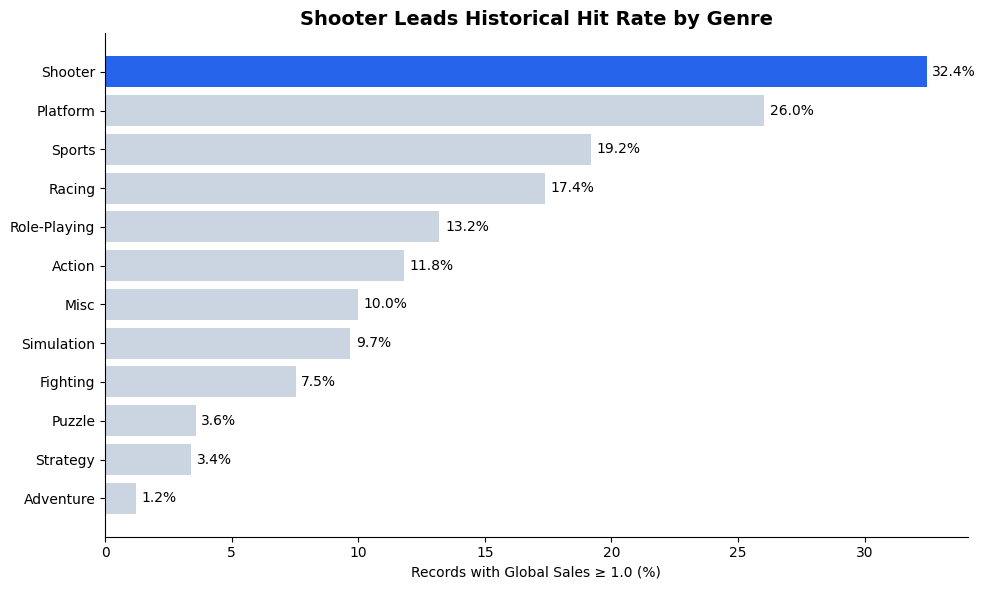

In [ ]:
import matplotlib.pyplot as plt

hit_rate_chart = (
    genre_summary
    .sort_values("hit_rate_pct", ascending=True)
    .copy()
)

highlight_genre = hit_rate_chart.loc[
    hit_rate_chart["hit_rate_pct"].idxmax(),
    "Genre"
]

colors = [
    "#2563EB" if genre == highlight_genre
    else "#CBD5E1"
    for genre in hit_rate_chart["Genre"]
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    hit_rate_chart["Genre"],
    hit_rate_chart["hit_rate_pct"],
    color=colors
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in hit_rate_chart["hit_rate_pct"]
    ],
    padding=4
)

ax.set_title(
    "Shooter Leads Historical Hit Rate by Genre",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Records with Global Sales ≥ 1.0 (%)"
)

ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
ax.set_title(
    "Shooter Had the Highest Historical Hit Rate by Genre, 2012–2015",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=15
)

ax.set_xlabel("Hit rate (%)")

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}% | n={int(records)}"
        for rate, records in zip(
            hit_rate_chart["hit_rate_pct"],
            hit_rate_chart["release_records"]
        )
    ],
    padding=4
)

fig.text(
    0.215,
    -0.02,
    "Hit = Global Sales ≥ 1.0; denominator = game-platform records within each genre. "
    "Sales units are not documented. Source: vgsales.csv.",
    fontsize=8,
    color="#555555"
)

plt.subplots_adjust(bottom=0.17)

<Figure size 640x480 with 0 Axes>

In [ ]:
concentration_for_merge = (
    fair_concentration
    .reset_index()[
        [
            "Genre",
            "top_10_pct_share"
        ]
    ]
)

genre_decision_matrix = genre_summary.merge(
    concentration_for_merge,
    on="Genre",
    how="left"
)

genre_decision_matrix[
    [
        "Genre",
        "release_records",
        "hit_rate_pct",
        "median_sales",
        "top_10_pct_share"
    ]
].round(2)

,Genre,release_records,hit_rate_pct,median_sales,top_10_pct_share
0,Shooter,188,32.45,0.55,51.30
1,Platform,73,26.03,0.28,52.43
2,Sports,224,19.20,0.29,49.26
3,Racing,92,17.39,0.22,52.60
4,Role-Playing,318,13.21,0.15,59.50
5,Action,855,11.81,0.14,58.26
6,Misc,160,10.00,0.18,62.63
7,Simulation,62,9.68,0.16,71.79
8,Fighting,93,7.53,0.16,56.43
9,Puzzle,28,3.57,0.04,56.16


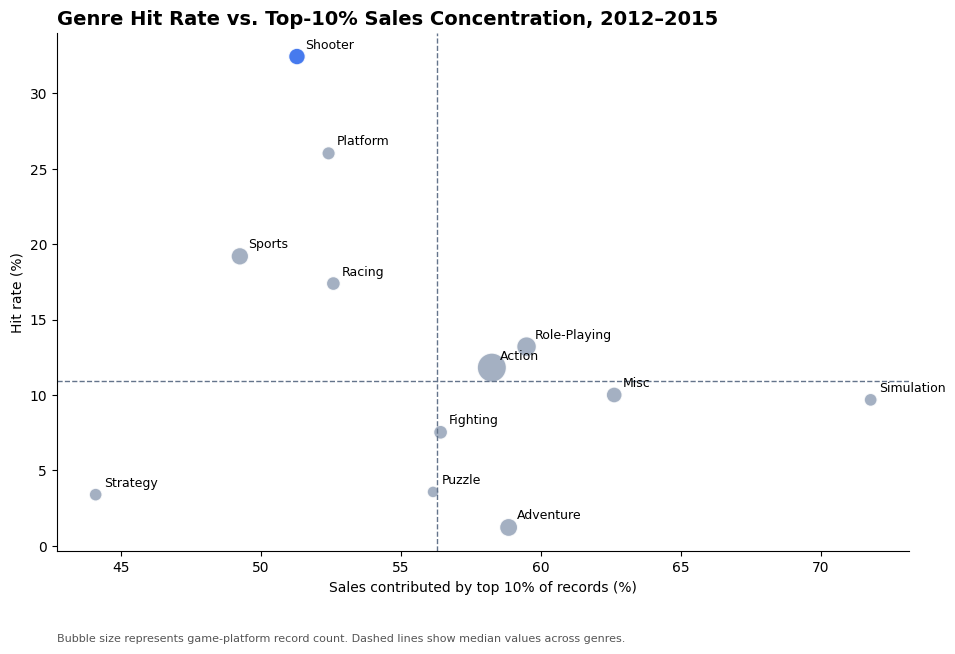

In [ ]:
import matplotlib.pyplot as plt

chart_data = genre_decision_matrix.copy()

x_median = chart_data["top_10_pct_share"].median()
y_median = chart_data["hit_rate_pct"].median()

bubble_sizes = (
    60 + chart_data["release_records"] * 0.45
)

colors = [
    "#2563EB" if genre == "Shooter"
    else "#94A3B8"
    for genre in chart_data["Genre"]
]

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    chart_data["top_10_pct_share"],
    chart_data["hit_rate_pct"],
    s=bubble_sizes,
    c=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=1
)

for _, row in chart_data.iterrows():
    ax.annotate(
        row["Genre"],
        (
            row["top_10_pct_share"],
            row["hit_rate_pct"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.axvline(
    x_median,
    color="#64748B",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y_median,
    color="#64748B",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Genre Hit Rate vs. Top-10% Sales Concentration, 2012–2015",
    fontsize=14,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel(
    "Sales contributed by top 10% of records (%)"
)

ax.set_ylabel(
    "Hit rate (%)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.125,
    0.01,
    "Bubble size represents game-platform record count. "
    "Dashed lines show median values across genres.",
    fontsize=8,
    color="#555555"
)

plt.subplots_adjust(bottom=0.14)
plt.show()

In [ ]:
regional_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
]

genre_region_sales = (
    games_recent
    .groupby("Genre")[regional_columns]
    .sum()
)

genre_region_sales.round(2)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,167.86,153.12,45.53,50.32
Adventure,8.11,8.77,7.04,2.76
Fighting,18.01,9.83,8.66,4.19
Misc,37.76,26.71,11.70,7.81
Platform,24.46,20.41,8.47,5.23
Puzzle,1.16,1.39,2.14,0.25
Racing,16.42,26.34,2.48,6.84
Role-Playing,57.85,44.67,58.67,13.79
Shooter,127.27,99.53,8.12,32.76


In [ ]:
genre_region_share = (
    genre_region_sales
    .div(
        genre_region_sales.sum(axis=0),
        axis=1
    )
    * 100
)

In [ ]:
genre_region_share = genre_region_share.rename(
    columns={
        "NA_Sales": "North America",
        "EU_Sales": "Europe",
        "JP_Sales": "Japan",
        "Other_Sales": "Other"
    }
)

genre_region_share.round(2)

,North America,Europe,Japan,Other
Genre,,,,
Action,30.83,32.72,26.39,34.08
Adventure,1.49,1.87,4.08,1.87
Fighting,3.31,2.10,5.02,2.84
Misc,6.93,5.71,6.78,5.29
Platform,4.49,4.36,4.91,3.54
Puzzle,0.21,0.30,1.24,0.17
Racing,3.02,5.63,1.44,4.63
Role-Playing,10.62,9.55,34.01,9.34
Shooter,23.37,21.27,4.71,22.18


In [ ]:
genre_region_share.sum().round(2)

,0
North America,100.0
Europe,100.0
Japan,100.0
Other,100.0


In [ ]:
genre_region_share.round(2).sort_values(
    "North America",
    ascending=False
)

,North America,Europe,Japan,Other
Genre,,,,
Action,30.83,32.72,26.39,34.08
Shooter,23.37,21.27,4.71,22.18
Sports,13.56,12.69,4.09,13.73
Role-Playing,10.62,9.55,34.01,9.34
Misc,6.93,5.71,6.78,5.29
Platform,4.49,4.36,4.91,3.54
Fighting,3.31,2.10,5.02,2.84
Racing,3.02,5.63,1.44,4.63
Adventure,1.49,1.87,4.08,1.87


In [ ]:
genre_region_share.round(2).T

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
North America,30.83,1.49,3.31,6.93,4.49,0.21,3.02,10.62,23.37,1.41,13.56,0.75
Europe,32.72,1.87,2.10,5.71,4.36,0.30,5.63,9.55,21.27,2.81,12.69,1.00
Japan,26.39,4.08,5.02,6.78,4.91,1.24,1.44,34.01,4.71,5.80,4.09,1.52
Other,34.08,1.87,2.84,5.29,3.54,0.17,4.63,9.34,22.18,1.60,13.73,0.74


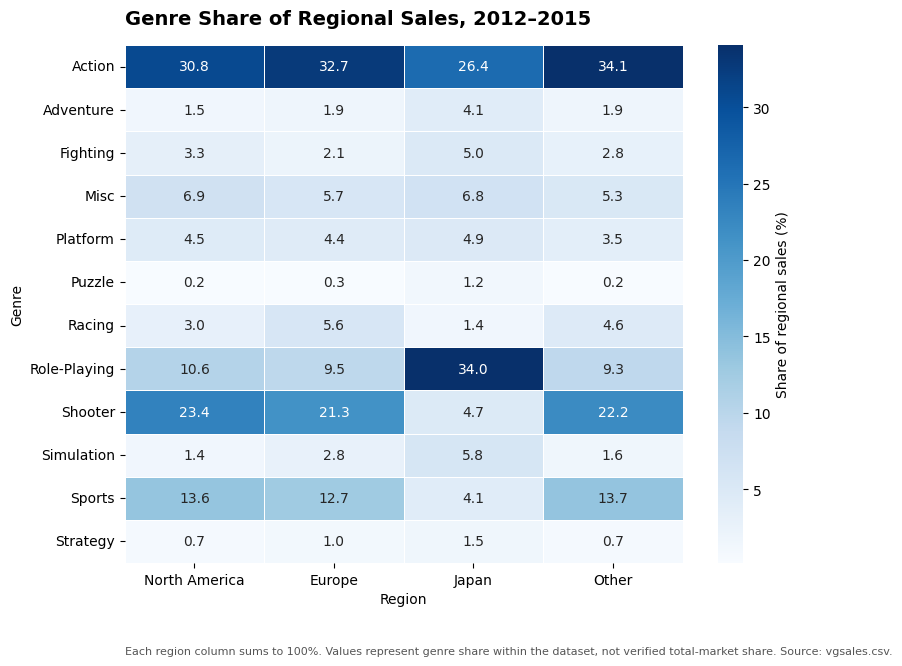

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = genre_region_share.copy()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Share of regional sales (%)"
    },
    ax=ax
)

ax.set_title(
    "Genre Share of Regional Sales, 2012–2015",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=15
)

ax.set_xlabel("Region")
ax.set_ylabel("Genre")

fig.text(
    0.125,
    0.01,
    "Each region column sums to 100%. Values represent genre share within the dataset, "
    "not verified total-market share. Source: vgsales.csv.",
    fontsize=8,
    color="#555555"
)

plt.subplots_adjust(bottom=0.14)
plt.show()

In [ ]:
fig.savefig(
    "genre_region_heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

In [ ]:
shooter_recent = games_clean[
    (games_clean["Genre"] == "Shooter")
    & (games_clean["Year"].between(2014, 2015))
].copy()

print("Shooter records:", len(shooter_recent))
print(
    "Platforms:",
    shooter_recent["Platform"].nunique()
)

Shooter records: 81
Platforms: 7


In [ ]:
shooter_platform_summary = (
    shooter_recent
    .groupby("Platform")
    .agg(
        release_records=("Name", "count"),
        total_global_sales=("Global_Sales", "sum"),
        average_sales=("Global_Sales", "mean"),
        median_sales=("Global_Sales", "median"),
        successful_records=(
            "Global_Sales",
            lambda sales: (
                sales >= SUCCESS_THRESHOLD
            ).sum()
        )
    )
    .reset_index()
)

In [ ]:
shooter_platform_summary["hit_rate_pct"] = (
    shooter_platform_summary["successful_records"]
    / shooter_platform_summary["release_records"]
    * 100
)

In [ ]:
shooter_platform_summary["sample_size_flag"] = (
    shooter_platform_summary[
        "release_records"
    ].apply(
        lambda count: (
            "Low sample"
            if count < 5
            else "Usable"
        )
    )
)

In [ ]:
shooter_platform_summary.sort_values(
    ["hit_rate_pct", "release_records"],
    ascending=[False, False]
).round(2)

,Platform,release_records,total_global_sales,average_sales,median_sales,successful_records,hit_rate_pct,sample_size_flag
6,XOne,21,42.37,2.02,1.20,13,61.90,Usable
2,PS4,18,53.37,2.96,1.65,11,61.11,Usable
4,WiiU,2,4.59,2.30,2.30,1,50.00,Low sample
5,X360,14,14.12,1.01,0.58,5,35.71,Usable
1,PS3,13,13.03,1.00,0.51,4,30.77,Usable
0,PC,12,3.84,0.32,0.26,0,0.00,Usable
3,PSV,1,0.83,0.83,0.83,0,0.00,Low sample


In [ ]:
import math
import pandas as pd

def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return (float("nan"), float("nan"))

    proportion = successes / total
    denominator = 1 + (z ** 2 / total)

    center = (
        proportion
        + z ** 2 / (2 * total)
    ) / denominator

    margin = (
        z
        * math.sqrt(
            proportion * (1 - proportion) / total
            + z ** 2 / (4 * total ** 2)
        )
        / denominator
    )

    return center - margin, center + margin

In [ ]:
confidence_intervals = (
    shooter_platform_summary
    .apply(
        lambda row: wilson_interval(
            row["successful_records"],
            row["release_records"]
        ),
        axis=1
    )
)

shooter_platform_summary[
    ["hit_rate_ci_low", "hit_rate_ci_high"]
] = pd.DataFrame(
    confidence_intervals.tolist(),
    index=shooter_platform_summary.index
) * 100

In [ ]:
shooter_platform_summary[
    [
        "Platform",
        "release_records",
        "hit_rate_pct",
        "hit_rate_ci_low",
        "hit_rate_ci_high",
        "median_sales",
        "total_global_sales",
        "sample_size_flag"
    ]
].sort_values(
    "hit_rate_pct",
    ascending=False
).round(2)

,Platform,release_records,hit_rate_pct,hit_rate_ci_low,hit_rate_ci_high,median_sales,total_global_sales,sample_size_flag
6,XOne,21,61.90,40.88,79.25,1.20,42.37,Usable
2,PS4,18,61.11,38.62,79.70,1.65,53.37,Usable
4,WiiU,2,50.00,9.45,90.55,2.30,4.59,Low sample
5,X360,14,35.71,16.34,61.24,0.58,14.12,Usable
1,PS3,13,30.77,12.68,57.63,0.51,13.03,Usable
0,PC,12,0.00,0.00,24.25,0.26,3.84,Usable
3,PSV,1,0.00,0.00,79.35,0.83,0.83,Low sample


In [ ]:
platform_region_sales = (
    shooter_recent
    .groupby("Platform")[regional_columns]
    .sum()
)

platform_region_sales.round(2)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Platform,,,,
PC,1.05,2.44,0.00,0.34
PS3,4.18,6.05,0.63,2.15
PS4,19.83,23.21,1.50,8.87
PSV,0.43,0.21,0.01,0.19
WiiU,1.57,1.15,1.44,0.43
X360,8.37,4.48,0.03,1.20
XOne,26.08,12.50,0.16,3.61


In [ ]:
platform_region_mix = (
    platform_region_sales
    .div(
        platform_region_sales.sum(axis=1),
        axis=0
    )
    * 100
)

In [ ]:
platform_region_mix = platform_region_mix.rename(
    columns={
        "NA_Sales": "North America",
        "EU_Sales": "Europe",
        "JP_Sales": "Japan",
        "Other_Sales": "Other"
    }
)

In [ ]:
platform_region_mix.loc[
    ["PS4", "XOne"]
].round(2)

,North America,Europe,Japan,Other
Platform,,,,
PS4,37.13,43.46,2.81,16.61
XOne,61.58,29.52,0.38,8.52


In [ ]:
platform_region_mix.loc[
    ["PS4", "XOne"]
].sum(axis=1).round(2)

,0
Platform,
PS4,100.0
XOne,100.0


Validate the recommendation using development cost, expected selling price, digital-sales coverage, platform install base and franchise-strength data before approving the portfolio budget.

In [ ]:
dashboard_columns = [
    "Rank",
    "Name",
    "Platform",
    "Year",
    "Genre",
    "Publisher",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales",
    "conflicting_duplicate_flag"
]

dashboard_data = games_recent[
    dashboard_columns
].copy()

dashboard_data.to_csv(
    "vgsales_dashboard_2012_2015.csv",
    index=False
)

dashboard_data.shape

(2399, 12)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')